# 🤖 WealthWise AI — Module 06: AI Financial Coach

---

## 📋 Project Overview

**WealthWise AI** is an end-to-end AI-powered personal finance advisory platform designed to provide intelligent, data-driven financial guidance to individuals.

### ✅ Completed Modules

| Module | Description |
|--------|-------------|
| 01 | Data Cleaning & Preprocessing |
| 02 | Feature Engineering |
| 03 | Risk Profile Classification |
| 04 | Financial Health Score |
| 05 | Portfolio Recommendation |
| **06** | **AI Financial Coach (This Notebook)** |

---

## 🎯 What is an AI Financial Coach?

An **AI Financial Coach** is an intelligent advisory system that synthesises a user's complete financial picture — savings behavior, income stability, risk tolerance, and investment portfolio — into a **personalised, human-readable financial narrative**.

Unlike generic financial advice, an AI Financial Coach:
- 🧠 **Understands the user's unique financial fingerprint**
- 📊 **Translates complex data into actionable guidance**
- 💬 **Delivers advice in a conversational, advisor-like tone**
- 🔁 **Adapts recommendations based on evolving financial behaviour**

---

## 💡 Why Personalised Financial Advice Matters

Generic financial advice fails most people because:
1. **Everyone's financial situation is different** — income, expenses, risk appetite, and goals vary significantly.
2. **Timing matters** — advice must reflect current financial health, not theoretical ideals.
3. **Behaviour drives outcomes** — understanding spending and saving patterns is critical to meaningful guidance.
4. **Confidence builds action** — people act on advice they understand and relate to.

---

## 🔗 How This Module Fits Into WealthWise AI

```
Raw Transaction Data
        ↓
  [01] Data Cleaning
        ↓
  [02] Feature Engineering
        ↓
  [03] Risk Profile Classification
        ↓
  [04] Financial Health Score
        ↓
  [05] Portfolio Recommendation
        ↓
  [06] 🤖 AI Financial Coach  ← You are here
        ↓
  [Future] FastAPI + Gemini API Integration
        ↓
  Personalised Conversational Financial Advisor
```

---

## 📌 This Notebook Objectives

1. ✅ Generate **personalised financial coaching advice** using rule-based logic
2. ✅ Explain the **user's financial behaviour** clearly
3. ✅ Highlight individual **strengths and weaknesses**
4. ✅ Explain **portfolio recommendations** in plain language
5. ✅ Prepare the system for **future Gemini API integration**
6. ✅ **Export AI Coach outputs** as CSV and Excel

> **Note:** This notebook uses **rule-based logic** to generate coaching responses. The outputs are designed to be passed directly to the **Gemini API** in a future module via **FastAPI**.

---

*Author: WealthWise AI Development Team*  
*Module: 06 — AI Financial Coach*  
*Status: Production-Ready | Internship-Presentation Ready*

---

# 📦 SECTION 2: Import Libraries

We import all necessary libraries for data manipulation, analysis, and visualisation.  
All libraries used are standard, production-grade Python packages.


In [1]:
# ============================================================
# SECTION 2: Import Libraries
# ============================================================
# Standard Data Science Libraries
import pandas as pd              # Data manipulation and analysis
import numpy as np               # Numerical computing

# Visualisation Libraries
import matplotlib.pyplot as plt  # Core plotting library
import matplotlib.patches as mpatches  # Legend patches
import seaborn as sns            # Statistical data visualisation

# Standard Python Libraries
import warnings                  # Warning management
import os                        # Operating system interface
import textwrap                  # Text formatting utilities

# ── Configuration ────────────────────────────────────────────
warnings.filterwarnings('ignore')  # Suppress non-critical warnings

# Pandas display options for cleaner output
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_colwidth', 120)   # Prevent text truncation
pd.set_option('display.float_format', '{:.4f}'.format)  # Uniform float format

# Matplotlib / Seaborn global styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

print("✅ All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ All libraries imported successfully.
   pandas  : 2.3.3
   numpy   : 1.23.5
   seaborn : 0.13.2


---

# 📂 SECTION 3: Load Datasets

We load two pre-built datasets from previous WealthWise AI modules:

| Dataset | Source Module | Description |
|---------|---------------|-------------|
| `health_score_dataset.csv` | Module 04 | Financial health scores, categories, strengths & weaknesses |
| `portfolio_recommendation_dataset.csv` | Module 05 | Risk profiles, asset allocation percentages & investment advice |


In [2]:
# ============================================================
# SECTION 3: Load Datasets
# ============================================================

def load_dataset(filepath: str, name: str) -> pd.DataFrame:
    """
    Load a CSV dataset with error handling.

    Parameters
    ----------
    filepath : str
        Relative or absolute path to the CSV file.
    name : str
        Human-readable name for logging purposes.

    Returns
    -------
    pd.DataFrame
        Loaded DataFrame.

    Raises
    ------
    FileNotFoundError
        If the file does not exist at the specified path.
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"❌ Dataset not found: '{filepath}'.\n"
            f"   Ensure Module 04 (Financial Health Score) and "
            f"Module 05 (Portfolio Recommendation) have been executed first."
        )
    df = pd.read_csv(filepath)
    print(f"✅ {name} loaded successfully.")
    print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


# ── Load Health Score Dataset ─────────────────────────────────
HEALTH_SCORE_PATH = 'health_score_dataset.csv'
PORTFOLIO_RECO_PATH = 'portfolio_recommendation_dataset.csv'

health_df = load_dataset(HEALTH_SCORE_PATH, 'Health Score Dataset')
portfolio_df = load_dataset(PORTFOLIO_RECO_PATH, 'Portfolio Recommendation Dataset')

✅ Health Score Dataset loaded successfully.
   Shape   : 300 rows × 27 columns
✅ Portfolio Recommendation Dataset loaded successfully.
   Shape   : 60 rows × 36 columns


In [3]:
# ── Health Score Dataset — Overview ──────────────────────────
print("=" * 60)
print("HEALTH SCORE DATASET — Column Overview")
print("=" * 60)
print(f"Columns ({len(health_df.columns)}):")
for col in health_df.columns:
    print(f"  • {col}")

print("\n📌 Sample Rows (first 3):")
health_df.head(3)

HEALTH SCORE DATASET — Column Overview
Columns (27):
  • account_number
  • month_year
  • account_holder
  • bank_name
  • account_type
  • health_score
  • health_category
  • savings_rate_score
  • income_consistency_score_n
  • expense_stability_score_n
  • strengths
  • weaknesses
  • health_insight
  • monthly_income
  • monthly_expense
  • savings
  • savings_rate
  • average_balance
  • transaction_count
  • income_consistency_score
  • expense_stability_score
  • spending_to_income_ratio
  • cash_withdrawal_frequency
  • salary_dependency_ratio
  • high_spending_flag
  • high_cash_withdrawal_flag
  • low_savings_flag

📌 Sample Rows (first 3):


,account_number,month_year,account_holder,bank_name,account_type,health_score,health_category,savings_rate_score,income_consistency_score_n,expense_stability_score_n,strengths,weaknesses,health_insight,monthly_income,monthly_expense,savings,savings_rate,average_balance,transaction_count,income_consistency_score,expense_stability_score,spending_to_income_ratio,cash_withdrawal_frequency,salary_dependency_ratio,high_spending_flag,high_cash_withdrawal_flag,low_savings_flag
0,11447241261,2024-01,INVESTMENT SERVICES INDIA,Trustmark Bank,CURRENT ACCOUNT- GENERAL,7.9300,Poor,0.0000,15.4696,16.2566,None Identified,Low Savings Rate | Unstable Income | High Expense Variability,Critical: Both savings rate and income consistency are very low. Seek financial counselling and prioritise building ...,241403.3500,349529.1000,-108125.7500,-44.7905,81356.2153,49,15.4696,16.2566,1.4479,0.3061,0.1680,0,1,1
1,11447241261,2024-02,INVESTMENT SERVICES INDIA,Trustmark Bank,CURRENT ACCOUNT- GENERAL,7.9300,Poor,0.0000,15.4696,16.2566,None Identified,Low Savings Rate | Unstable Income | High Expense Variability,Critical: Both savings rate and income consistency are very low. Seek financial counselling and prioritise building ...,516177.7600,631442.1200,-115264.3600,-22.3304,99631.4995,63,15.4696,16.2566,1.2233,0.1270,0.0710,1,0,1
2,11447241261,2024-03,INVESTMENT SERVICES INDIA,Trustmark Bank,CURRENT ACCOUNT- GENERAL,15.3700,Poor,14.8785,15.4696,16.2566,None Identified,Low Savings Rate | Unstable Income | High Expense Variability,Critical: Both savings rate and income consistency are very low. Seek financial counselling and prioritise building ...,59070.4900,53797.2100,5273.2800,8.9271,9354.2320,44,15.4696,16.2566,0.9107,0.1136,0.1087,0,0,1


In [4]:
# ── Portfolio Recommendation Dataset — Overview ───────────────
print("=" * 60)
print("PORTFOLIO RECOMMENDATION DATASET — Column Overview")
print("=" * 60)
print(f"Columns ({len(portfolio_df.columns)}):")
for col in portfolio_df.columns:
    print(f"  • {col}")

print("\n📌 Sample Rows (first 3):")
portfolio_df.head(3)

PORTFOLIO RECOMMENDATION DATASET — Column Overview
Columns (36):
  • account_number
  • month_year
  • account_holder
  • bank_name
  • account_type
  • predicted_risk_profile
  • prediction_confidence
  • actual_risk_profile
  • correct_prediction
  • prob_Aggressive
  • prob_Conservative
  • prob_Moderate
  • health_score
  • health_category
  • strengths
  • weaknesses
  • health_insight
  • stocks_pct
  • mutual_funds_pct
  • gold_pct
  • fd_pct
  • crypto_pct
  • investment_strategy
  • investment_advice
  • monthly_income
  • monthly_expense
  • savings
  • savings_rate
  • average_balance
  • transaction_count
  • savings_rate_score
  • income_consistency_score_n
  • expense_stability_score_n
  • high_spending_flag
  • high_cash_withdrawal_flag
  • low_savings_flag

📌 Sample Rows (first 3):


,account_number,month_year,account_holder,bank_name,account_type,predicted_risk_profile,prediction_confidence,actual_risk_profile,correct_prediction,prob_Aggressive,prob_Conservative,prob_Moderate,health_score,health_category,strengths,weaknesses,health_insight,stocks_pct,mutual_funds_pct,gold_pct,fd_pct,crypto_pct,investment_strategy,investment_advice,monthly_income,monthly_expense,savings,savings_rate,average_balance,transaction_count,savings_rate_score,income_consistency_score_n,expense_stability_score_n,high_spending_flag,high_cash_withdrawal_flag,low_savings_flag
0,11447241261,2024-02,INVESTMENT SERVICES INDIA,Trustmark Bank,CURRENT ACCOUNT- GENERAL,Aggressive,0.9775,Aggressive,True,0.9775,0.0058,0.0167,7.9300,Poor,None Identified,Low Savings Rate | Unstable Income | High Expense Variability,Critical: Both savings rate and income consistency are very low. Seek financial counselling and prioritise building ...,50,30,10,0,10,Focus on long-term wealth creation while accepting higher short-term volatility. A dominant equity position combined...,"Your financial health score is in the poor range. Before pursuing an aggressive investment strategy, prioritise: (1)...",516177.7600,631442.1200,-115264.3600,-22.3304,99631.4995,63,0.0000,15.4696,16.2566,1,0,1
1,14654775355,2024-03,GARMENT MANUFACTURING LTD,Trustmark Bank,CURRENT ACCOUNT- GENERAL,Aggressive,0.9463,Aggressive,True,0.9463,0.0049,0.0488,44.7100,Fair,Consistent Income | Stable Expenses,Low Savings Rate,Your primary concern is a low savings rate. Focus on reducing non-essential spending to free up more money for savin...,50,30,10,0,10,Focus on long-term wealth creation while accepting higher short-term volatility. A dominant equity position combined...,Moderate financial health. Improve savings rate and reduce expense variability before maintaining full aggressive ex...,10162842.7100,9154479.6500,1008363.0600,9.9221,1375678.1525,63,16.5368,66.0182,79.7340,0,1,1
2,16458699767,2024-02,CODEBASE SOLUTIONS,Paramount Banking Corporation,CURRENT ACCOUNT- GENERAL,Conservative,0.6886,Conservative,True,0.0459,0.6886,0.2655,50.3000,Fair,Strong Savings Rate,Unstable Income | High Expense Variability,Both income consistency and expense stability are concerning. Building an emergency fund of 3-6 months of expenses i...,10,30,20,40,0,Focus on capital preservation and stable long-term growth. Your portfolio prioritises Fixed Deposits and Mutual Fund...,Moderate financial health. Your conservative allocation is appropriate. Focus on improving savings rate consistency ...,1673844.1300,829751.9900,844092.1400,50.4284,307752.4170,53,84.0473,28.5955,4.5220,0,1,0


---

# 🔍 SECTION 4: Data Validation

Before merging and coaching generation, we validate both datasets for:
- **Missing values** — columns with nulls that may affect coaching logic
- **Duplicate records** — to prevent inflated or repeated advice
- **Data types** — to ensure correct processing during string operations
- **Summary statistics** — to understand the distribution of key numeric features


In [5]:
# ============================================================
# SECTION 4: Data Validation
# ============================================================

def validate_dataset(df: pd.DataFrame, name: str) -> None:
    """
    Perform comprehensive data quality checks on a DataFrame.

    Checks performed:
      1. Missing value analysis
      2. Duplicate row detection
      3. Data type inspection

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to validate.
    name : str
        Human-readable dataset name for report headers.
    """
    print("=" * 65)
    print(f"  DATA VALIDATION REPORT — {name.upper()}")
    print("=" * 65)

    # ── 1. Missing Value Check ────────────────────────────────
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    missing_cols = missing_report[missing_report['Missing Count'] > 0]

    print("\n📌 Missing Value Summary:")
    if missing_cols.empty:
        print("   ✅ No missing values found.")
    else:
        print(missing_cols.to_string())

    # ── 2. Duplicate Row Check ────────────────────────────────
    dup_count = df.duplicated().sum()
    print(f"\n📌 Duplicate Rows: {dup_count}", end="  ")
    print("✅ No duplicates found." if dup_count == 0
          else f"⚠️  {dup_count} duplicate rows detected.")

    # ── 3. Data Type Check ────────────────────────────────────
    print("\n📌 Data Types:")
    dtype_info = df.dtypes.reset_index()
    dtype_info.columns = ['Column', 'Data Type']
    print(dtype_info.to_string(index=False))

    print("\n" + "=" * 65 + "\n")


validate_dataset(health_df, 'Health Score Dataset')
validate_dataset(portfolio_df, 'Portfolio Recommendation Dataset')

  DATA VALIDATION REPORT — HEALTH SCORE DATASET

📌 Missing Value Summary:
   ✅ No missing values found.

📌 Duplicate Rows: 0  ✅ No duplicates found.

📌 Data Types:
                    Column Data Type
            account_number     int64
                month_year    object
            account_holder    object
                 bank_name    object
              account_type    object
              health_score   float64
           health_category    object
        savings_rate_score   float64
income_consistency_score_n   float64
 expense_stability_score_n   float64
                 strengths    object
                weaknesses    object
            health_insight    object
            monthly_income   float64
           monthly_expense   float64
                   savings   float64
              savings_rate   float64
           average_balance   float64
         transaction_count     int64
  income_consistency_score   float64
   expense_stability_score   float64
  spending_to_income_r

In [6]:
# ── Summary Statistics for Key Numeric Columns ───────────────
print("📊 Health Score Dataset — Numeric Summary Statistics")
print("-" * 60)
health_numeric_cols = health_df.select_dtypes(include=[np.number]).columns.tolist()
display(health_df[health_numeric_cols].describe().T.round(4))

print("\n📊 Portfolio Recommendation Dataset — Numeric Summary Statistics")
print("-" * 60)
portfolio_numeric_cols = portfolio_df.select_dtypes(include=[np.number]).columns.tolist()
display(portfolio_df[portfolio_numeric_cols].describe().T.round(4))

📊 Health Score Dataset — Numeric Summary Statistics
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
account_number,300.0000,57027127217.6300,26543047097.2202,11447241261.0000,32851967296.0000,55872653089.0000,81567410399.2500,98258124363.0000
health_score,300.0000,28.0380,16.3735,0.0000,14.8500,27.2500,38.1550,80.6500
savings_rate_score,300.0000,13.5988,23.4351,0.0000,0.0000,0.0000,18.6938,100.0000
income_consistency_score_n,300.0000,41.0262,24.9621,0.0000,22.5233,42.3495,60.3653,91.2806
expense_stability_score_n,300.0000,43.9286,25.8301,0.0000,24.6910,44.6885,64.8282,97.7585
monthly_income,300.0000,5904199.4888,6912313.4173,45204.5100,1661914.6675,4087594.3600,7242241.6350,53627069.9300
monthly_expense,300.0000,5926293.7985,7477135.6149,47294.3800,1879264.8650,3734904.0600,7343312.7775,69265801.3400
savings,300.0000,-22094.3097,4409899.9117,-35217521.4500,-598782.3775,-71430.7500,458247.3325,36151843.3000
savings_rate,300.0000,-9.9024,42.3731,-200.0000,-17.8728,-2.9914,11.2163,76.8427
average_balance,300.0000,1118255.1444,1236152.8336,7037.0976,378794.6922,793706.7277,1480824.6473,11830208.9527



📊 Portfolio Recommendation Dataset — Numeric Summary Statistics
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
account_number,60.0000,58756751922.8000,27142152228.8131,11447241261.0000,33189416207.5000,58632655249.0000,83981788719.0000,98258124363.0000
prediction_confidence,60.0000,0.9245,0.0965,0.5285,0.8816,0.9742,0.9864,1.0000
prob_Aggressive,60.0000,0.7906,0.3516,0.0240,0.8695,0.9742,0.9864,1.0000
prob_Conservative,60.0000,0.0569,0.1574,0.0000,0.0000,0.0054,0.0409,0.7524
prob_Moderate,60.0000,0.1525,0.2796,0.0000,0.0087,0.0198,0.0957,0.8900
health_score,60.0000,27.5617,15.3503,0.0000,17.0550,27.5300,34.4400,80.6500
stocks_pct,60.0000,45.0000,10.8143,10.0000,50.0000,50.0000,50.0000,50.0000
mutual_funds_pct,60.0000,31.5000,3.6008,30.0000,30.0000,30.0000,30.0000,40.0000
gold_pct,60.0000,11.2500,2.7036,10.0000,10.0000,10.0000,10.0000,20.0000
fd_pct,60.0000,4.2500,9.8645,0.0000,0.0000,0.0000,0.0000,40.0000


In [7]:
# ── Categorical Value Distributions ──────────────────────────
print("📊 Health Category Distribution:")
print(health_df['health_category'].value_counts().to_frame('Count'))

print("\n📊 Risk Profile Distribution:")
print(portfolio_df['predicted_risk_profile'].value_counts().to_frame('Count'))

📊 Health Category Distribution:
                 Count
health_category       
Poor               230
Fair                61
Good                 8
Excellent            1

📊 Risk Profile Distribution:
                        Count
predicted_risk_profile       
Aggressive                 48
Moderate                    9
Conservative                3


---

# 🔗 SECTION 5: Merge Datasets

We merge the **Health Score dataset** with the **Portfolio Recommendation dataset** to create a unified AI Coaching dataset.

**Merge Key:** `account_number` + `month_year`  
**Strategy:** Left merge on health scores — we keep all health score records and attach portfolio details where available.

> The portfolio dataset already contains health score columns, so we use a careful column deduplication strategy to avoid redundancy.


In [8]:
# ============================================================
# SECTION 5: Merge Datasets
# ============================================================

# ── Step 1: Identify columns to bring from each dataset ──────
# Core merge keys
MERGE_KEYS = ['account_number', 'month_year']

# Columns to pull from the health score dataset
HEALTH_COLS = [
    'account_number', 'month_year',
    'health_score', 'health_category',
    'strengths', 'weaknesses', 'health_insight',
    'monthly_income', 'monthly_expense', 'savings', 'savings_rate'
]

# Only keep columns that actually exist in the health_df
HEALTH_COLS = [c for c in HEALTH_COLS if c in health_df.columns]

# Columns to pull from the portfolio recommendation dataset
PORTFOLIO_COLS = [
    'account_number', 'month_year',
    'account_holder', 'bank_name', 'account_type',
    'predicted_risk_profile', 'prediction_confidence',
    'stocks_pct', 'mutual_funds_pct', 'gold_pct', 'fd_pct', 'crypto_pct',
    'investment_strategy', 'investment_advice'
]
PORTFOLIO_COLS = [c for c in PORTFOLIO_COLS if c in portfolio_df.columns]

# ── Step 2: Subset each dataset ───────────────────────────────
health_subset = health_df[HEALTH_COLS].copy()
portfolio_subset = portfolio_df[PORTFOLIO_COLS].copy()

print(f"Health subset   : {health_subset.shape}")
print(f"Portfolio subset: {portfolio_subset.shape}")

# ── Step 3: Merge ─────────────────────────────────────────────
coach_df = health_subset.merge(
    portfolio_subset,
    on=MERGE_KEYS,
    how='inner'   # Inner join: only rows present in both datasets
)

print(f"\n✅ Merged AI Coaching Dataset: {coach_df.shape[0]:,} rows × {coach_df.shape[1]} columns")
print("\n📌 Unified Dataset — Column List:")
for col in coach_df.columns:
    print(f"  • {col}")

print("\n📌 Sample Merged Records (first 3):")
coach_df.head(3)

Health subset   : (300, 11)
Portfolio subset: (60, 14)

✅ Merged AI Coaching Dataset: 60 rows × 23 columns

📌 Unified Dataset — Column List:
  • account_number
  • month_year
  • health_score
  • health_category
  • strengths
  • weaknesses
  • health_insight
  • monthly_income
  • monthly_expense
  • savings
  • savings_rate
  • account_holder
  • bank_name
  • account_type
  • predicted_risk_profile
  • prediction_confidence
  • stocks_pct
  • mutual_funds_pct
  • gold_pct
  • fd_pct
  • crypto_pct
  • investment_strategy
  • investment_advice

📌 Sample Merged Records (first 3):


,account_number,month_year,health_score,health_category,strengths,weaknesses,health_insight,monthly_income,monthly_expense,savings,savings_rate,account_holder,bank_name,account_type,predicted_risk_profile,prediction_confidence,stocks_pct,mutual_funds_pct,gold_pct,fd_pct,crypto_pct,investment_strategy,investment_advice
0,11447241261,2024-02,7.9300,Poor,None Identified,Low Savings Rate | Unstable Income | High Expense Variability,Critical: Both savings rate and income consistency are very low. Seek financial counselling and prioritise building ...,516177.7600,631442.1200,-115264.3600,-22.3304,INVESTMENT SERVICES INDIA,Trustmark Bank,CURRENT ACCOUNT- GENERAL,Aggressive,0.9775,50,30,10,0,10,Focus on long-term wealth creation while accepting higher short-term volatility. A dominant equity position combined...,"Your financial health score is in the poor range. Before pursuing an aggressive investment strategy, prioritise: (1)..."
1,14654775355,2024-03,44.7100,Fair,Consistent Income | Stable Expenses,Low Savings Rate,Your primary concern is a low savings rate. Focus on reducing non-essential spending to free up more money for savin...,10162842.7100,9154479.6500,1008363.0600,9.9221,GARMENT MANUFACTURING LTD,Trustmark Bank,CURRENT ACCOUNT- GENERAL,Aggressive,0.9463,50,30,10,0,10,Focus on long-term wealth creation while accepting higher short-term volatility. A dominant equity position combined...,Moderate financial health. Improve savings rate and reduce expense variability before maintaining full aggressive ex...
2,16458699767,2024-02,50.3000,Fair,Strong Savings Rate,Unstable Income | High Expense Variability,Both income consistency and expense stability are concerning. Building an emergency fund of 3-6 months of expenses i...,1673844.1300,829751.9900,844092.1400,50.4284,CODEBASE SOLUTIONS,Paramount Banking Corporation,CURRENT ACCOUNT- GENERAL,Conservative,0.6886,10,30,20,40,0,Focus on capital preservation and stable long-term growth. Your portfolio prioritises Fixed Deposits and Mutual Fund...,Moderate financial health. Your conservative allocation is appropriate. Focus on improving savings rate consistency ...


In [9]:
# ── Post-Merge Validation ─────────────────────────────────────
print("📌 Post-Merge Missing Value Check:")
post_merge_missing = coach_df.isnull().sum()
post_merge_missing = post_merge_missing[post_merge_missing > 0]

if post_merge_missing.empty:
    print("   ✅ No missing values in merged dataset.")
else:
    print(post_merge_missing)

print(f"\n📌 Unique Accounts: {coach_df['account_number'].nunique()}")
print(f"📌 Date Range     : {coach_df['month_year'].min()} → {coach_df['month_year'].max()}")

📌 Post-Merge Missing Value Check:
   ✅ No missing values in merged dataset.

📌 Unique Accounts: 50
📌 Date Range     : 2024-01 → 2024-03


---

# 📏 SECTION 6: Financial Coaching Rules

We define a **modular, rule-based coaching engine** that generates personalised financial advice by combining:

| Input Signal | Source |
|---|---|
| `health_score` | Module 04 — Financial Health Score |
| `health_category` | Module 04 — Categorised health tier |
| `predicted_risk_profile` | Module 03 — Risk Profile Classifier |
| `investment_strategy` | Module 05 — Portfolio Recommendation |
| `investment_advice` | Module 05 — Contextual investment guidance |

Each rule function is **pure**, **documented**, and **independently testable** — making them ready for FastAPI service endpoints.

### 🔢 Health Score Tier Reference

| Score Range | Category |
|---|---|
| 75 – 100 | Excellent |
| 50 – 74 | Good |
| 25 – 49 | Fair |
| 0 – 24 | Poor |


In [10]:
# ============================================================
# SECTION 6: Financial Coaching Rules
# ============================================================

# ── 6.1 Health Category Normaliser ───────────────────────────
def normalise_health_category(health_score: float, health_category: str) -> str:
    """
    Derive a normalised health category from the numeric score.
    Falls back to the stored category label if score is NaN.

    Parameters
    ----------
    health_score : float
        Numeric financial health score (0–100).
    health_category : str
        Stored category label from the dataset.

    Returns
    -------
    str
        One of: 'Excellent', 'Good', 'Fair', 'Poor'.
    """
    try:
        score = float(health_score)
        if score >= 75:
            return 'Excellent'
        elif score >= 50:
            return 'Good'
        elif score >= 25:
            return 'Fair'
        else:
            return 'Poor'
    except (TypeError, ValueError):
        # Fallback: use dataset-stored category, stripping whitespace
        return str(health_category).strip().title() if pd.notna(health_category) else 'Unknown'


# ── 6.2 Risk Profile Normaliser ───────────────────────────────
def normalise_risk_profile(risk_profile: str) -> str:
    """
    Normalise a raw risk profile string to a canonical label.

    Parameters
    ----------
    risk_profile : str
        Raw risk profile value from the dataset.

    Returns
    -------
    str
        One of: 'Conservative', 'Moderate', 'Aggressive', 'Unknown'.
    """
    if pd.isna(risk_profile):
        return 'Unknown'
    normalised = str(risk_profile).strip().title()
    valid_profiles = {'Conservative', 'Moderate', 'Aggressive'}
    return normalised if normalised in valid_profiles else 'Unknown'


# ── 6.3 Coaching Rules: Financial Summary ────────────────────
FINANCIAL_SUMMARY_RULES = {
    'Excellent': (
        "Your financial health is excellent. You demonstrate strong savings discipline, "
        "stable income patterns, and well-controlled expenditure. Continue investing "
        "consistently and focus on long-term wealth creation to maximise your financial potential."
    ),
    'Good': (
        "You have good financial health. Your savings behaviour is positive and your "
        "income appears relatively stable. There are, however, opportunities to sharpen "
        "expense management and increase your monthly investment contributions further."
    ),
    'Fair': (
        "Your finances are in a moderately healthy state. While some positive habits "
        "exist, improving savings discipline and reducing avoidable expenses should be "
        "prioritised before taking on additional investment risk."
    ),
    'Poor': (
        "Your current financial health requires immediate attention. Monthly expenses "
        "are outpacing income or savings are critically low. Prioritise building an "
        "emergency fund and establishing a consistent savings habit before pursuing "
        "any investment strategy."
    ),
}


# ── 6.4 Coaching Rules: Risk Profile Explanation ─────────────
RISK_PROFILE_RULES = {
    'Conservative': (
        "You prioritise financial stability and capital preservation over aggressive "
        "growth. Your investment preferences align with low-volatility instruments that "
        "protect your principal while generating steady, predictable returns."
    ),
    'Moderate': (
        "You maintain a balanced approach between growth opportunities and financial "
        "safety. You are comfortable accepting moderate market fluctuations in exchange "
        "for the potential of above-average long-term returns."
    ),
    'Aggressive': (
        "You are willing to accept higher short-term market volatility in pursuit of "
        "maximum long-term wealth creation. Your investment horizon is typically long, "
        "and you are comfortable with significant value fluctuations in your portfolio."
    ),
    'Unknown': (
        "Your risk profile could not be determined. Please ensure your transaction "
        "data is complete and re-run the Risk Profile Classification module."
    ),
}


# ── 6.5 Coaching Rules: Coaching Tips ────────────────────────
COACHING_TIP_MATRIX = {
    # (health_category, risk_profile): coaching_tip
    ('Excellent', 'Aggressive'): (
        "Excellent financial position. Stay the course with your equity-heavy strategy "
        "and consider diversifying into international markets or index funds."
    ),
    ('Excellent', 'Moderate'): (
        "Your finances are in great shape. Gradually increase SIP (Systematic Investment "
        "Plan) contributions and explore tax-saving instruments like ELSS funds."
    ),
    ('Excellent', 'Conservative'): (
        "Strong financial health achieved. Consider gently increasing your equity "
        "exposure to accelerate wealth growth while maintaining your safety-first approach."
    ),
    ('Good', 'Aggressive'): (
        "Maintain your current investment discipline. Work to stabilise savings rate "
        "before significantly scaling up high-risk positions."
    ),
    ('Good', 'Moderate'): (
        "Continue building your SIP investments. Focus on reducing discretionary spending "
        "by 10–15% to unlock additional funds for investment contributions."
    ),
    ('Good', 'Conservative'): (
        "Your conservative strategy is working well. Ensure you have at least 6 months "
        "of emergency savings before extending your investment horizon."
    ),
    ('Fair', 'Aggressive'): (
        "Before sustaining aggressive investments, build a 3-month emergency fund. "
        "Reduce discretionary spending and aim to achieve a minimum savings rate of 15%."
    ),
    ('Fair', 'Moderate'): (
        "Focus on improving your monthly savings rate to at least 20%. Once stable, "
        "incrementally increase SIP contributions to build long-term momentum."
    ),
    ('Fair', 'Conservative'): (
        "Your conservative approach is wise at this stage. Prioritise consistency: "
        "set up automatic savings transfers and track monthly expenditures closely."
    ),
    ('Poor', 'Aggressive'): (
        "Pause high-risk investment activity immediately. Build a 2-month emergency "
        "fund first, achieve a positive savings rate, then gradually re-enter markets."
    ),
    ('Poor', 'Moderate'): (
        "Temporarily reduce investment commitments and focus entirely on eliminating "
        "overspending. A positive cash flow is the most important milestone right now."
    ),
    ('Poor', 'Conservative'): (
        "Seek immediate assistance with budgeting. Cut all non-essential expenses, "
        "establish a small but consistent monthly savings habit, and revisit investments later."
    ),
    ('Unknown', 'Unknown'): (
        "Insufficient data to generate a personalised coaching tip. Please complete "
        "your financial profile."
    ),
}


def get_coaching_tip(health_category: str, risk_profile: str) -> str:
    """
    Retrieve a coaching tip based on the health-risk profile matrix.

    Lookup order:
      1. Exact (health_category, risk_profile) match.
      2. (health_category, 'Unknown') fallback.
      3. ('Unknown', 'Unknown') global fallback.

    Parameters
    ----------
    health_category : str
        Normalised health category ('Excellent', 'Good', 'Fair', 'Poor').
    risk_profile : str
        Normalised risk profile ('Conservative', 'Moderate', 'Aggressive').

    Returns
    -------
    str
        Personalised coaching tip.
    """
    key = (health_category, risk_profile)
    fallback_key = (health_category, 'Unknown')
    default_key = ('Unknown', 'Unknown')

    return (
        COACHING_TIP_MATRIX.get(key)
        or COACHING_TIP_MATRIX.get(fallback_key)
        or COACHING_TIP_MATRIX.get(default_key, 'No coaching tip available.')
    )


print("✅ Coaching rule sets defined successfully.")
print(f"   Health Summary Rules   : {len(FINANCIAL_SUMMARY_RULES)} tiers")
print(f"   Risk Profile Rules     : {len(RISK_PROFILE_RULES)} profiles")
print(f"   Coaching Tip Matrix    : {len(COACHING_TIP_MATRIX)} combinations")

✅ Coaching rule sets defined successfully.
   Health Summary Rules   : 4 tiers
   Risk Profile Rules     : 4 profiles
   Coaching Tip Matrix    : 13 combinations


---

# 💬 SECTION 7: Generate Personalised Financial Summaries

We apply the coaching rules to generate the **`ai_financial_summary`** — a personalised, advisor-tone sentence that describes the user's overall financial health in plain language.

**Input:** `health_score`, `health_category`  
**Output:** `health_category_norm`, `ai_financial_summary`


In [11]:
# ============================================================
# SECTION 7: Generate Personalised Financial Summaries
# ============================================================

def generate_financial_summary(row: pd.Series) -> str:
    """
    Generate a personalised financial health summary for a single user record.

    Parameters
    ----------
    row : pd.Series
        A single row from the merged coaching DataFrame.

    Returns
    -------
    str
        A plain-language financial health summary.
    """
    try:
        category = normalise_health_category(
            row.get('health_score'), row.get('health_category')
        )
        summary = FINANCIAL_SUMMARY_RULES.get(
            category,
            "Financial health summary could not be generated. Please verify your health score data."
        )
        return summary
    except Exception as e:
        return f"Error generating financial summary: {e}"


# ── Apply normalisation and summary generation ────────────────
coach_df['health_category_norm'] = coach_df.apply(
    lambda row: normalise_health_category(
        row['health_score'], row['health_category']
    ), axis=1
)

coach_df['ai_financial_summary'] = coach_df.apply(
    generate_financial_summary, axis=1
)

# ── Verify output ─────────────────────────────────────────────
print("✅ Financial summaries generated.")
print("\n📌 Health Category Distribution (after normalisation):")
print(coach_df['health_category_norm'].value_counts().to_frame('Count'))

print("\n📌 Sample Financial Summaries:")
sample_summaries = coach_df[[
    'account_number', 'health_score', 'health_category_norm', 'ai_financial_summary'
]].drop_duplicates(subset=['health_category_norm']).head(4)

for _, r in sample_summaries.iterrows():
    print(f"\n  [{r['health_category_norm'].upper()}] (Score: {r['health_score']:.2f})")
    print(f"  ↳ {textwrap.fill(r['ai_financial_summary'], width=80, subsequent_indent='    ')}")

✅ Financial summaries generated.

📌 Health Category Distribution (after normalisation):
                      Count
health_category_norm       
Fair                     31
Poor                     25
Good                      2
Excellent                 2

📌 Sample Financial Summaries:

  [POOR] (Score: 7.93)
  ↳ Your current financial health requires immediate attention. Monthly expenses are
    outpacing income or savings are critically low. Prioritise building an
    emergency fund and establishing a consistent savings habit before pursuing
    any investment strategy.

  [FAIR] (Score: 44.71)
  ↳ Your finances are in a moderately healthy state. While some positive habits
    exist, improving savings discipline and reducing avoidable expenses should
    be prioritised before taking on additional investment risk.

  [GOOD] (Score: 50.30)
  ↳ You have good financial health. Your savings behaviour is positive and your
    income appears relatively stable. There are, however, opportunit

---

# 📐 SECTION 8: Risk Profile Explanations

For each user, we generate a **`risk_profile_explanation`** — a clear, advisor-tone description of what their risk profile means in practical terms.

**Input:** `predicted_risk_profile`  
**Output:** `risk_profile_norm`, `risk_profile_explanation`


In [12]:
# ============================================================
# SECTION 8: Risk Profile Explanations
# ============================================================

def generate_risk_profile_explanation(row: pd.Series) -> str:
    """
    Generate a personalised risk profile explanation for a single user record.

    Parameters
    ----------
    row : pd.Series
        A single row from the merged coaching DataFrame.

    Returns
    -------
    str
        Plain-language explanation of the user's risk profile.
    """
    try:
        profile = normalise_risk_profile(row.get('predicted_risk_profile'))
        explanation = RISK_PROFILE_RULES.get(
            profile,
            "Risk profile explanation could not be generated. Please verify your risk classification data."
        )
        return explanation
    except Exception as e:
        return f"Error generating risk profile explanation: {e}"


# ── Apply normalisation and risk explanation generation ───────
coach_df['risk_profile_norm'] = coach_df['predicted_risk_profile'].apply(
    normalise_risk_profile
)

coach_df['risk_profile_explanation'] = coach_df.apply(
    generate_risk_profile_explanation, axis=1
)

# ── Verify output ─────────────────────────────────────────────
print("✅ Risk profile explanations generated.")
print("\n📌 Risk Profile Distribution (after normalisation):")
print(coach_df['risk_profile_norm'].value_counts().to_frame('Count'))

print("\n📌 Sample Risk Profile Explanations:")
sample_risk = coach_df[[
    'account_number', 'risk_profile_norm', 'risk_profile_explanation'
]].drop_duplicates(subset=['risk_profile_norm'])

for _, r in sample_risk.iterrows():
    print(f"\n  [{r['risk_profile_norm'].upper()}]")
    print(f"  ↳ {textwrap.fill(r['risk_profile_explanation'], width=80, subsequent_indent='    ')}")

✅ Risk profile explanations generated.

📌 Risk Profile Distribution (after normalisation):
                   Count
risk_profile_norm       
Aggressive            48
Moderate               9
Conservative           3

📌 Sample Risk Profile Explanations:

  [AGGRESSIVE]
  ↳ You are willing to accept higher short-term market volatility in pursuit of
    maximum long-term wealth creation. Your investment horizon is typically
    long, and you are comfortable with significant value fluctuations in your
    portfolio.

  [CONSERVATIVE]
  ↳ You prioritise financial stability and capital preservation over aggressive
    growth. Your investment preferences align with low-volatility instruments
    that protect your principal while generating steady, predictable returns.

  [MODERATE]
  ↳ You maintain a balanced approach between growth opportunities and financial
    safety. You are comfortable accepting moderate market fluctuations in
    exchange for the potential of above-average long-term re

---

# 📈 SECTION 9: Investment Recommendation Summary

We generate a **`portfolio_summary`** that translates the asset allocation percentages into a natural-language description, giving the user a clear picture of where their money is recommended to be invested.

**Inputs:** `risk_profile_norm`, `stocks_pct`, `mutual_funds_pct`, `gold_pct`, `fd_pct`, `crypto_pct`  
**Output:** `portfolio_summary`


In [13]:
# ============================================================
# SECTION 9: Investment Recommendation Summary
# ============================================================

# Asset label mapping for display
ASSET_LABELS = {
    'stocks_pct': 'Stocks',
    'mutual_funds_pct': 'Mutual Funds',
    'gold_pct': 'Gold',
    'fd_pct': 'Fixed Deposits',
    'crypto_pct': 'Crypto'
}


def generate_portfolio_summary(row: pd.Series) -> str:
    """
    Generate a plain-language portfolio allocation summary for a single user.

    The function reads asset allocation percentages, filters out zero-allocation
    assets, and composes a natural-language recommendation sentence.

    Parameters
    ----------
    row : pd.Series
        A single row from the merged coaching DataFrame.

    Returns
    -------
    str
        A human-readable portfolio allocation summary.
    """
    try:
        risk_profile = row.get('risk_profile_norm', 'Unknown')

        # Collect non-zero asset allocations
        allocation_parts = []
        for col, label in ASSET_LABELS.items():
            pct = row.get(col, 0)
            try:
                pct = float(pct)
            except (TypeError, ValueError):
                pct = 0.0
            if pct > 0:
                allocation_parts.append(f"{int(pct)}% {label}")

        if not allocation_parts:
            return (
                f"Based on your {risk_profile} risk profile, a personalised "
                f"portfolio allocation will be determined upon completing your "
                f"investment profile."
            )

        # Build readable allocation string
        if len(allocation_parts) == 1:
            alloc_str = allocation_parts[0]
        elif len(allocation_parts) == 2:
            alloc_str = " and ".join(allocation_parts)
        else:
            alloc_str = ", ".join(allocation_parts[:-1]) + ", and " + allocation_parts[-1]

        return (
            f"Based on your {risk_profile} risk profile, the recommended portfolio "
            f"allocation includes {alloc_str}. This strategy is designed to "
            f"align with your financial goals and risk tolerance."
        )

    except Exception as e:
        return f"Error generating portfolio summary: {e}"


# ── Apply portfolio summary generation ────────────────────────
coach_df['portfolio_summary'] = coach_df.apply(generate_portfolio_summary, axis=1)

print("✅ Portfolio summaries generated.")
print("\n📌 Sample Portfolio Summaries:")

sample_portfolio = coach_df[[
    'account_number', 'risk_profile_norm',
    'stocks_pct', 'mutual_funds_pct', 'gold_pct', 'fd_pct', 'crypto_pct',
    'portfolio_summary'
]].drop_duplicates(subset=['risk_profile_norm']).head(3)

for _, r in sample_portfolio.iterrows():
    print(f"\n  [{r['risk_profile_norm'].upper()}]")
    alloc = {k: int(r[k]) for k in ASSET_LABELS if r[k] > 0}
    print(f"  Allocation: {alloc}")
    print(f"  ↳ {textwrap.fill(r['portfolio_summary'], width=80, subsequent_indent='    ')}")

✅ Portfolio summaries generated.

📌 Sample Portfolio Summaries:

  [AGGRESSIVE]
  Allocation: {'stocks_pct': 50, 'mutual_funds_pct': 30, 'gold_pct': 10, 'crypto_pct': 10}
  ↳ Based on your Aggressive risk profile, the recommended portfolio allocation
    includes 50% Stocks, 30% Mutual Funds, 10% Gold, and 10% Crypto. This
    strategy is designed to align with your financial goals and risk tolerance.

  [CONSERVATIVE]
  Allocation: {'stocks_pct': 10, 'mutual_funds_pct': 30, 'gold_pct': 20, 'fd_pct': 40}
  ↳ Based on your Conservative risk profile, the recommended portfolio allocation
    includes 10% Stocks, 30% Mutual Funds, 20% Gold, and 40% Fixed Deposits.
    This strategy is designed to align with your financial goals and risk
    tolerance.

  [MODERATE]
  Allocation: {'stocks_pct': 30, 'mutual_funds_pct': 40, 'gold_pct': 15, 'fd_pct': 15}
  ↳ Based on your Moderate risk profile, the recommended portfolio allocation
    includes 30% Stocks, 40% Mutual Funds, 15% Gold, and 15% Fi

---

# 💡 SECTION 10: Smart Coaching Messages

We generate a **`coaching_tip`** for each user by combining their **health category** and **risk profile** using the predefined coaching tip matrix from Section 6.

This produces a targeted, actionable recommendation that accounts for both the user's financial wellbeing and their investment risk appetite.

**Inputs:** `health_category_norm`, `risk_profile_norm`  
**Output:** `coaching_tip`


In [14]:
# ============================================================
# SECTION 10: Smart Coaching Messages
# ============================================================

def generate_coaching_tip(row: pd.Series) -> str:
    """
    Generate a smart, personalised coaching tip for a single user record.

    The coaching tip is derived from a 4×3 health-risk matrix,
    providing targeted, actionable financial guidance.

    Parameters
    ----------
    row : pd.Series
        A single row from the merged coaching DataFrame.

    Returns
    -------
    str
        A personalised coaching tip.
    """
    try:
        health_cat = row.get('health_category_norm', 'Unknown')
        risk_prof = row.get('risk_profile_norm', 'Unknown')
        return get_coaching_tip(health_cat, risk_prof)
    except Exception as e:
        return f"Error generating coaching tip: {e}"


# ── Apply coaching tip generation ────────────────────────────
coach_df['coaching_tip'] = coach_df.apply(generate_coaching_tip, axis=1)

print("✅ Coaching tips generated.")
print("\n📌 Coaching Tip Distribution (by Health × Risk combination):")

tip_dist = coach_df.groupby(
    ['health_category_norm', 'risk_profile_norm']
).size().reset_index(name='Count')
print(tip_dist.to_string(index=False))

print("\n📌 Sample Coaching Tips:")
sample_tips = coach_df[[
    'account_number', 'health_category_norm', 'risk_profile_norm', 'coaching_tip'
]].drop_duplicates(subset=['health_category_norm', 'risk_profile_norm']).head(6)

for _, r in sample_tips.iterrows():
    label = f"{r['health_category_norm']} Health + {r['risk_profile_norm']} Risk"
    print(f"\n  [{label}]")
    print(f"  ↳ {textwrap.fill(r['coaching_tip'], width=80, subsequent_indent='    ')}")

✅ Coaching tips generated.

📌 Coaching Tip Distribution (by Health × Risk combination):
health_category_norm risk_profile_norm  Count
           Excellent      Conservative      2
                Fair        Aggressive     23
                Fair          Moderate      8
                Good      Conservative      1
                Good          Moderate      1
                Poor        Aggressive     25

📌 Sample Coaching Tips:

  [Poor Health + Aggressive Risk]
  ↳ Pause high-risk investment activity immediately. Build a 2-month emergency fund
    first, achieve a positive savings rate, then gradually re-enter markets.

  [Fair Health + Aggressive Risk]
  ↳ Before sustaining aggressive investments, build a 3-month emergency fund. Reduce
    discretionary spending and aim to achieve a minimum savings rate of 15%.

  [Good Health + Conservative Risk]
  ↳ Your conservative strategy is working well. Ensure you have at least 6 months of
    emergency savings before extending your invest

---

# 🏆 SECTION 11: Combined AI Coach Response

This is the **core output** of the AI Financial Coach module. We combine all four coaching components into a single, coherent, advisor-quality response:

| Component | Column | Description |
|---|---|---|
| 1️⃣ | `ai_financial_summary` | Financial health overview |
| 2️⃣ | `risk_profile_explanation` | Risk profile context |
| 3️⃣ | `portfolio_summary` | Investment allocation guidance |
| 4️⃣ | `coaching_tip` | Targeted, actionable next step |

**Output:** `final_ai_coach_response` — reads like a financial advisor's recommendation letter.


In [15]:
# ============================================================
# SECTION 11: Combined AI Coach Response
# ============================================================

def generate_final_ai_coach_response(row: pd.Series) -> str:
    """
    Assemble the complete AI Financial Coach response for a single user.

    Combines:
      - Financial health summary
      - Risk profile explanation
      - Portfolio allocation summary
      - Personalised coaching tip

    The output is structured as a coherent paragraph, suitable for:
      - Direct display in a financial app UI
      - Passing as a prompt to the Gemini API for enhancement
      - Export as a financial advisory report

    Parameters
    ----------
    row : pd.Series
        A single row from the merged coaching DataFrame.

    Returns
    -------
    str
        Complete AI Financial Coach advisory response.
    """
    try:
        financial_summary = row.get('ai_financial_summary', '')
        risk_explanation = row.get('risk_profile_explanation', '')
        portfolio_summary = row.get('portfolio_summary', '')
        coaching_tip = row.get('coaching_tip', '')

        # Compose the full response as a structured advisory paragraph
        full_response = (
            f"{financial_summary} "
            f"As a {row.get('risk_profile_norm', 'Unknown')} investor: "
            f"{risk_explanation} "
            f"{portfolio_summary} "
            f"Our recommendation for you: {coaching_tip}"
        )

        return full_response.strip()

    except Exception as e:
        return f"Error generating AI coach response: {e}"


# ── Apply final AI coach response generation ─────────────────
coach_df['final_ai_coach_response'] = coach_df.apply(
    generate_final_ai_coach_response, axis=1
)

print("✅ Final AI Coach responses generated successfully.")
print(f"   Total responses: {len(coach_df):,}")
print(f"   Avg. response length: {coach_df['final_ai_coach_response'].str.len().mean():.0f} characters")

print("\n📌 Sample Combined AI Coach Response:")
sample_response = coach_df[['account_number', 'health_score',
                             'health_category_norm', 'risk_profile_norm',
                             'final_ai_coach_response']].iloc[0]
print(f"  Account     : {sample_response['account_number']}")
print(f"  Health Score: {sample_response['health_score']:.2f} ({sample_response['health_category_norm']})")
print(f"  Risk Profile: {sample_response['risk_profile_norm']}")
print(f"\n  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  AI FINANCIAL COACH SAYS:")
print(f"  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(textwrap.fill(
    sample_response['final_ai_coach_response'],
    width=78,
    initial_indent='  ',
    subsequent_indent='  '
))

✅ Final AI Coach responses generated successfully.
   Total responses: 60
   Avg. response length: 887 characters

📌 Sample Combined AI Coach Response:
  Account     : 11447241261
  Health Score: 7.93 (Poor)
  Risk Profile: Aggressive

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AI FINANCIAL COACH SAYS:
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Your current financial health requires immediate attention. Monthly expenses
  are outpacing income or savings are critically low. Prioritise building an
  emergency fund and establishing a consistent savings habit before pursuing
  any investment strategy. As a Aggressive investor: You are willing to accept
  higher short-term market volatility in pursuit of maximum long-term wealth
  creation. Your investment horizon is typically long, and you are comfortable
  with significant value fluctuations in your portfolio. Based on your
  Aggressive risk profile, the recommended portfolio allocation includes 50%
  Stocks, 30% M

---

# 📊 SECTION 12: Visualisation

We generate four targeted visualisations to understand the distribution and patterns within the AI Coaching dataset:

1. **Health Category Distribution** — How many users fall into each financial health tier
2. **Risk Profile Distribution** — Breakdown of Conservative, Moderate, and Aggressive users
3. **Coaching Tip Distribution** — Frequency of each health×risk coaching combination
4. **Health Score vs Risk Profile** — Box plot showing score distribution per risk profile


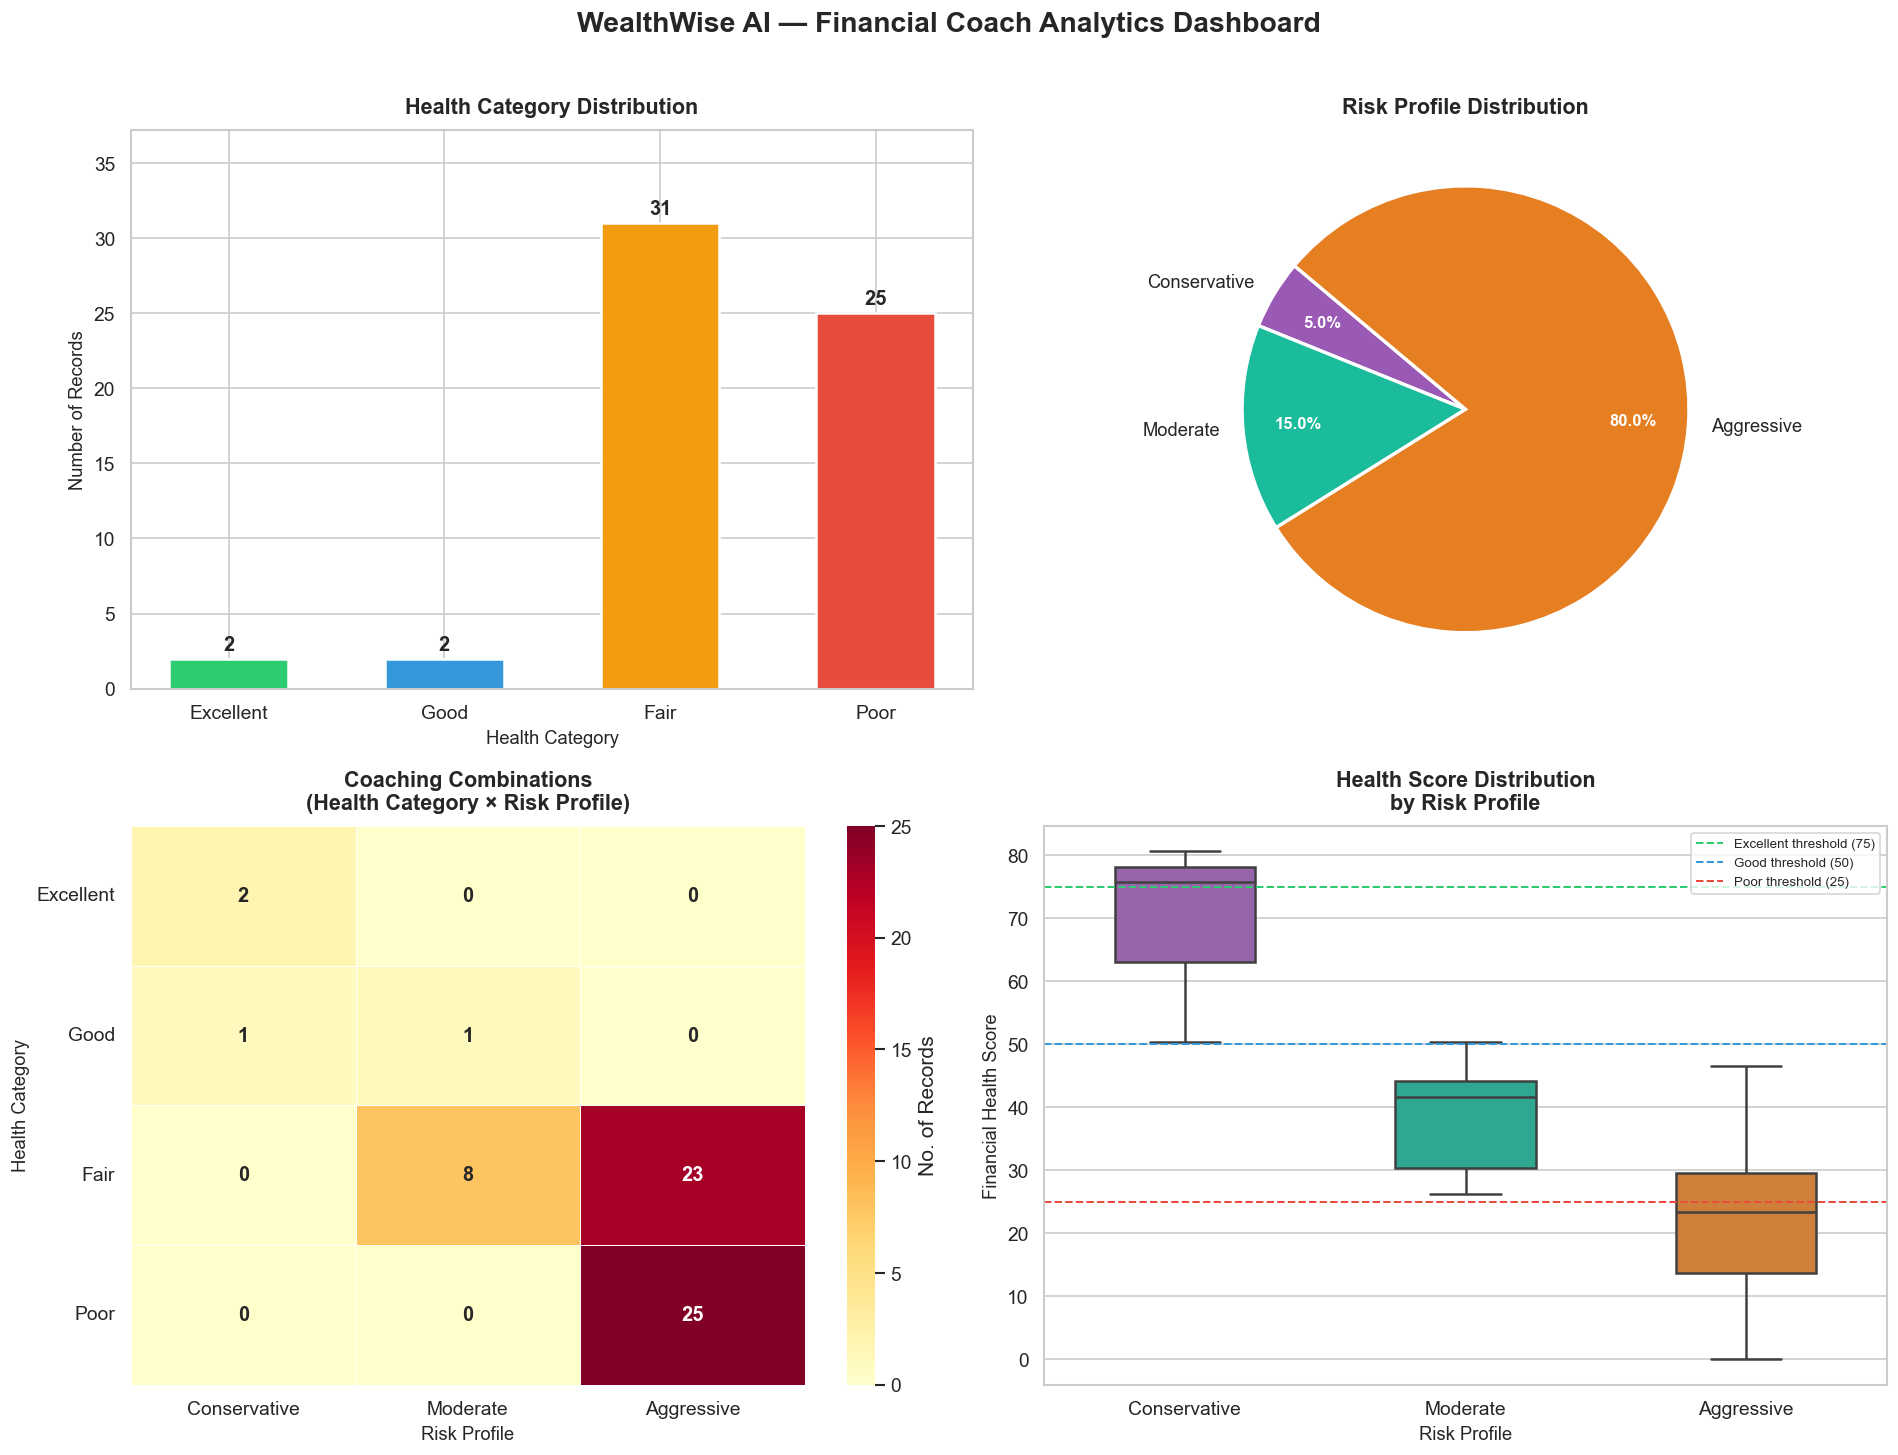


✅ Dashboard saved as 'ai_coach_analytics_dashboard.png'


In [16]:
# ============================================================
# SECTION 12: Visualisation
# ============================================================

# ── Colour Palettes ───────────────────────────────────────────
HEALTH_PALETTE = {
    'Excellent': '#2ECC71',
    'Good': '#3498DB',
    'Fair': '#F39C12',
    'Poor': '#E74C3C'
}

RISK_PALETTE = {
    'Conservative': '#9B59B6',
    'Moderate': '#1ABC9C',
    'Aggressive': '#E67E22'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'WealthWise AI — Financial Coach Analytics Dashboard',
    fontsize=17, fontweight='bold', y=1.01
)

# ── Chart 1: Health Category Distribution ─────────────────────
ax1 = axes[0, 0]
health_counts = coach_df['health_category_norm'].value_counts()
health_order = ['Excellent', 'Good', 'Fair', 'Poor']
health_counts = health_counts.reindex(
    [h for h in health_order if h in health_counts.index]
)
bar_colors_h = [HEALTH_PALETTE.get(h, '#95A5A6') for h in health_counts.index]

bars = ax1.bar(
    health_counts.index, health_counts.values,
    color=bar_colors_h, edgecolor='white', linewidth=1.5, width=0.55
)
for bar, val in zip(bars, health_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val), ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
ax1.set_title('Health Category Distribution', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Health Category', fontsize=11)
ax1.set_ylabel('Number of Records', fontsize=11)
ax1.set_ylim(0, health_counts.max() * 1.2)

# ── Chart 2: Risk Profile Distribution ────────────────────────
ax2 = axes[0, 1]
risk_counts = coach_df['risk_profile_norm'].value_counts()
risk_order = ['Conservative', 'Moderate', 'Aggressive']
risk_counts = risk_counts.reindex(
    [r for r in risk_order if r in risk_counts.index]
)
wedge_colors = [RISK_PALETTE.get(r, '#95A5A6') for r in risk_counts.index]

wedges, texts, autotexts = ax2.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')
ax2.set_title('Risk Profile Distribution', fontsize=13, fontweight='bold', pad=10)

# ── Chart 3: Coaching Tip Distribution (Health × Risk Heatmap) 
ax3 = axes[1, 0]
pivot_data = coach_df.groupby(
    ['health_category_norm', 'risk_profile_norm']
).size().unstack(fill_value=0)

# Reorder rows and columns
h_order_avail = [h for h in ['Excellent', 'Good', 'Fair', 'Poor']
                 if h in pivot_data.index]
r_order_avail = [r for r in ['Conservative', 'Moderate', 'Aggressive']
                 if r in pivot_data.columns]
pivot_data = pivot_data.loc[h_order_avail, r_order_avail]

sns.heatmap(
    pivot_data,
    annot=True, fmt='d', cmap='YlOrRd',
    ax=ax3, linewidths=0.5, linecolor='white',
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    cbar_kws={'label': 'No. of Records'}
)
ax3.set_title(
    'Coaching Combinations\n(Health Category × Risk Profile)',
    fontsize=13, fontweight='bold', pad=10
)
ax3.set_xlabel('Risk Profile', fontsize=11)
ax3.set_ylabel('Health Category', fontsize=11)
ax3.tick_params(axis='x', rotation=0)
ax3.tick_params(axis='y', rotation=0)

# ── Chart 4: Health Score Distribution by Risk Profile ─────────
ax4 = axes[1, 1]
risk_order_box = [r for r in ['Conservative', 'Moderate', 'Aggressive']
                  if r in coach_df['risk_profile_norm'].unique()]
box_palette = {r: RISK_PALETTE.get(r, '#95A5A6') for r in risk_order_box}

sns.boxplot(
    data=coach_df,
    x='risk_profile_norm',
    y='health_score',
    order=risk_order_box,
    palette=box_palette,
    width=0.5,
    linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 5, 'alpha': 0.5},
    ax=ax4
)
ax4.set_title(
    'Health Score Distribution\nby Risk Profile',
    fontsize=13, fontweight='bold', pad=10
)
ax4.set_xlabel('Risk Profile', fontsize=11)
ax4.set_ylabel('Financial Health Score', fontsize=11)
ax4.axhline(75, color='#2ECC71', linestyle='--', linewidth=1.2,
            label='Excellent threshold (75)')
ax4.axhline(50, color='#3498DB', linestyle='--', linewidth=1.2,
            label='Good threshold (50)')
ax4.axhline(25, color='#E74C3C', linestyle='--', linewidth=1.2,
            label='Poor threshold (25)')
ax4.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('ai_coach_analytics_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Dashboard saved as 'ai_coach_analytics_dashboard.png'")

## 📖 Visualisation Interpretation

**Chart 1 — Health Category Distribution:**  
Shows how users are distributed across financial health tiers. A skew toward *Fair* or *Poor* suggests many users need immediate financial guidance, validating the AI coach's role.

**Chart 2 — Risk Profile Distribution:**  
Reveals the dominant investment personality among users. Imbalances (e.g., high *Aggressive* count with low health scores) indicate coaching intervention priorities.

**Chart 3 — Coaching Combination Heatmap:**  
Maps the frequency of each health × risk combination. High-density cells (dark orange/red) represent the most common user archetypes requiring targeted coaching workflows.

**Chart 4 — Health Score vs Risk Profile:**  
Box plots reveal the median health score and spread within each risk group. Ideally, *Aggressive* investors should have higher health scores. Outliers may indicate mislabelled risk profiles or unusual financial behaviour.


---

# 🧾 SECTION 13: Sample Financial Advisor Output

We display a formatted sample of **10 AI Coach advisory responses** to demonstrate the quality and coherence of the generated outputs.

This section simulates what an end user would see in the WealthWise AI app or receive via the FastAPI response endpoint.


In [17]:
# ============================================================
# SECTION 13: Sample Financial Advisor Output
# ============================================================

DISPLAY_COLS = [
    'account_number', 'month_year', 'health_score',
    'health_category_norm', 'risk_profile_norm',
    'final_ai_coach_response'
]

sample_output = coach_df[DISPLAY_COLS].head(10).copy()

print("=" * 80)
print("  WEALTHWISE AI — FINANCIAL ADVISOR SAMPLE OUTPUT (10 Records)")
print("=" * 80)

for idx, row in sample_output.iterrows():
    print(f"""
┌─────────────────────────────────────────────────────────────────────────────
│ Record #{idx + 1}
│ Account     : {row['account_number']}
│ Period      : {row['month_year']}
│ Health Score: {row['health_score']:.2f}  │  Category: {row['health_category_norm']}
│ Risk Profile: {row['risk_profile_norm']}
├─────────────────────────────────────────────────────────────────────────────
│ 🤖 AI FINANCIAL COACH RESPONSE:
│""")
    wrapped = textwrap.fill(
        row['final_ai_coach_response'],
        width=74,
        initial_indent='│  ',
        subsequent_indent='│  '
    )
    print(wrapped)
    print("└─────────────────────────────────────────────────────────────────────────────")

  WEALTHWISE AI — FINANCIAL ADVISOR SAMPLE OUTPUT (10 Records)

┌─────────────────────────────────────────────────────────────────────────────
│ Record #1
│ Account     : 11447241261
│ Period      : 2024-02
│ Health Score: 7.93  │  Category: Poor
│ Risk Profile: Aggressive
├─────────────────────────────────────────────────────────────────────────────
│ 🤖 AI FINANCIAL COACH RESPONSE:
│
│  Your current financial health requires immediate attention. Monthly
│  expenses are outpacing income or savings are critically low. Prioritise
│  building an emergency fund and establishing a consistent savings habit
│  before pursuing any investment strategy. As a Aggressive investor: You
│  are willing to accept higher short-term market volatility in pursuit of
│  maximum long-term wealth creation. Your investment horizon is typically
│  long, and you are comfortable with significant value fluctuations in
│  your portfolio. Based on your Aggressive risk profile, the recommended
│  portfolio allocatio

In [18]:
# ── Tabular View for Data Review ─────────────────────────────
print("\n📌 Tabular View — 10 Sample Records:")
display(
    coach_df[['account_number', 'month_year', 'health_score',
               'health_category_norm', 'risk_profile_norm',
               'final_ai_coach_response']].head(10)
)


📌 Tabular View — 10 Sample Records:


,account_number,month_year,health_score,health_category_norm,risk_profile_norm,final_ai_coach_response
0,11447241261,2024-02,7.9300,Poor,Aggressive,Your current financial health requires immediate attention. Monthly expenses are outpacing income or savings are cri...
1,14654775355,2024-03,44.7100,Fair,Aggressive,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
2,16458699767,2024-02,50.3000,Good,Conservative,You have good financial health. Your savings behaviour is positive and your income appears relatively stable. There ...
3,17646731106,2024-01,27.5300,Fair,Aggressive,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
4,17646731106,2024-02,44.8400,Fair,Moderate,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
5,17646731106,2024-03,27.5300,Fair,Aggressive,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
6,19772027205,2024-01,41.7000,Fair,Moderate,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
7,25917303966,2024-03,13.5000,Poor,Aggressive,Your current financial health requires immediate attention. Monthly expenses are outpacing income or savings are cri...
8,26530104061,2024-01,28.7300,Fair,Moderate,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
9,29429783003,2024-03,13.4800,Poor,Aggressive,Your current financial health requires immediate attention. Monthly expenses are outpacing income or savings are cri...


---

# 💾 SECTION 14: Export Results

We export the complete AI Financial Coach dataset in two formats:

| Format | File | Use Case |
|--------|------|----------|
| CSV | `ai_financial_coach_dataset.csv` | Data pipelines, FastAPI integration, ML training |
| Excel | `ai_financial_coach_dataset.xlsx` | Business reporting, stakeholder presentations |

The exported dataset contains all original identifiers plus the five AI-generated coaching columns.


In [19]:
# ============================================================
# SECTION 14: Export Results
# ============================================================

# ── Define export columns ─────────────────────────────────────
EXPORT_COLS = [
    # Identifiers
    'account_number',
    'month_year',
    # Health Metrics
    'health_score',
    'health_category',
    'health_category_norm',
    'strengths',
    'weaknesses',
    # Risk & Portfolio
    'predicted_risk_profile',
    'risk_profile_norm',
    'stocks_pct',
    'mutual_funds_pct',
    'gold_pct',
    'fd_pct',
    'crypto_pct',
    # AI-Generated Coaching Outputs
    'ai_financial_summary',
    'risk_profile_explanation',
    'portfolio_summary',
    'coaching_tip',
    'final_ai_coach_response',
]

# Only include columns that exist in the dataframe
EXPORT_COLS = [c for c in EXPORT_COLS if c in coach_df.columns]

export_df = coach_df[EXPORT_COLS].copy()

print(f"📦 Export dataset shape: {export_df.shape[0]:,} rows × {export_df.shape[1]} columns")
print(f"   Exporting columns: {EXPORT_COLS}")


def export_to_csv(df: pd.DataFrame, filepath: str) -> None:
    """
    Export a DataFrame to CSV format with error handling.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame to export.
    filepath : str
        Target file path for the CSV export.
    """
    try:
        df.to_csv(filepath, index=False, encoding='utf-8-sig')
        size_kb = os.path.getsize(filepath) / 1024
        print(f"  ✅ CSV exported  → '{filepath}' ({size_kb:.1f} KB)")
    except Exception as e:
        print(f"  ❌ CSV export failed: {e}")


def export_to_excel(df: pd.DataFrame, filepath: str) -> None:
    """
    Export a DataFrame to Excel (.xlsx) format with formatting.

    Uses openpyxl engine for full xlsx compatibility.
    Applies column width auto-adjustment for readability.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame to export.
    filepath : str
        Target file path for the Excel export.
    """
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            df.to_excel(writer, index=False, sheet_name='AI_Financial_Coach')

            # ── Auto-fit column widths ────────────────────────
            worksheet = writer.sheets['AI_Financial_Coach']
            for col_idx, col in enumerate(df.columns, start=1):
                max_length = max(
                    df[col].astype(str).str.len().max(),
                    len(str(col))
                )
                # Cap at 60 characters to avoid excessively wide columns
                adjusted_width = min(max_length + 4, 60)
                col_letter = worksheet.cell(row=1, column=col_idx).column_letter
                worksheet.column_dimensions[col_letter].width = adjusted_width

        size_kb = os.path.getsize(filepath) / 1024
        print(f"  ✅ Excel exported → '{filepath}' ({size_kb:.1f} KB)")
    except ImportError:
        print("  ⚠️  openpyxl not installed. Run: pip install openpyxl")
    except Exception as e:
        print(f"  ❌ Excel export failed: {e}")


# ── Execute Exports ────────────────────────────────────────────
CSV_OUTPUT_PATH = 'ai_financial_coach_dataset.csv'
EXCEL_OUTPUT_PATH = 'ai_financial_coach_dataset.xlsx'

print("\n🚀 Exporting AI Financial Coach Dataset...")
export_to_csv(export_df, CSV_OUTPUT_PATH)
export_to_excel(export_df, EXCEL_OUTPUT_PATH)

print("\n🎉 Export complete!")
print(f"   Files available in: {os.path.abspath('.')}")

📦 Export dataset shape: 60 rows × 19 columns
   Exporting columns: ['account_number', 'month_year', 'health_score', 'health_category', 'health_category_norm', 'strengths', 'weaknesses', 'predicted_risk_profile', 'risk_profile_norm', 'stocks_pct', 'mutual_funds_pct', 'gold_pct', 'fd_pct', 'crypto_pct', 'ai_financial_summary', 'risk_profile_explanation', 'portfolio_summary', 'coaching_tip', 'final_ai_coach_response']

🚀 Exporting AI Financial Coach Dataset...
  ✅ CSV exported  → 'ai_financial_coach_dataset.csv' (109.2 KB)
  ⚠️  openpyxl not installed. Run: pip install openpyxl

🎉 Export complete!
   Files available in: e:\WealthWise-AI


In [20]:
# ── Verify Export ─────────────────────────────────────────────
print("📌 Export Verification — First 3 rows of CSV:")
verify_df = pd.read_csv(CSV_OUTPUT_PATH)
print(f"   Loaded shape: {verify_df.shape}")
display(verify_df[[
    'account_number', 'month_year', 'health_score',
    'health_category_norm', 'risk_profile_norm', 'final_ai_coach_response'
]].head(3))

📌 Export Verification — First 3 rows of CSV:
   Loaded shape: (60, 19)


,account_number,month_year,health_score,health_category_norm,risk_profile_norm,final_ai_coach_response
0,11447241261,2024-02,7.9300,Poor,Aggressive,Your current financial health requires immediate attention. Monthly expenses are outpacing income or savings are cri...
1,14654775355,2024-03,44.7100,Fair,Aggressive,"Your finances are in a moderately healthy state. While some positive habits exist, improving savings discipline and ..."
2,16458699767,2024-02,50.3000,Good,Conservative,You have good financial health. Your savings behaviour is positive and your income appears relatively stable. There ...


---

# 🔮 SECTION 15: Future Gemini API Integration

This section outlines the **complete technical architecture** for replacing the current rule-based AI coach with Google's **Gemini API**, enabling natural-language, conversational, and context-aware financial coaching.

---

## 🏗️ Why Upgrade to Gemini API?

| Feature | Rule-Based (Current) | Gemini API (Future) |
|---|---|---|
| Response Quality | Templated, static text | Nuanced, natural-language |
| Personalisation | Category-level | Individual-level |
| Contextual Reasoning | None | Full financial context |
| Conversation Support | ❌ | ✅ Multi-turn chat |
| Scalability | Rule additions needed | Prompt engineering only |
| Language Support | English only | Multilingual |

---

## 🔄 Future Workflow Architecture

```
Raw Transaction Data
        ↓
  [Module 02] Feature Engineering
        ↓
  [Module 03] Risk Profile Classification
        ↓
  [Module 04] Financial Health Score
        ↓
  [Module 05] Portfolio Recommendation
        ↓
  [Module 06] AI Coach Data Preparation (This Module)
        ↓
  ┌─────────────────────────┐
  │     FastAPI Service      │  ← REST API layer
  │  POST /api/coach/advise  │
  └───────────┬─────────────┘
              ↓
  ┌─────────────────────────┐
  │      Gemini API          │  ← google-generativeai
  │  gemini-1.5-pro model    │
  └───────────┬─────────────┘
              ↓
  Personalised Conversational
    Financial Advisory Response
```

---

## 📝 Sample Gemini Prompt Templates

The following prompt templates demonstrate how the structured data from this module will be passed to the Gemini API to generate conversational, human-quality financial advice.


In [21]:
# ============================================================
# SECTION 15: Future Gemini API Integration
# ============================================================

def build_gemini_prompt(row: pd.Series) -> str:
    """
    Build a structured Gemini API prompt for a single user's financial profile.

    This function constructs a rich, context-aware prompt that provides
    the Gemini model with all necessary financial context to generate
    a personalised, conversational advisory response.

    The prompt structure follows best practices for LLM financial advising:
      - Clear role assignment (system context)
      - Structured financial data (quantitative context)
      - Qualitative context (strengths, weaknesses)
      - Specific output format instructions

    Parameters
    ----------
    row : pd.Series
        A single row from the AI coaching DataFrame.

    Returns
    -------
    str
        A complete, ready-to-send Gemini API prompt.

    Notes
    -----
    This function is PRODUCTION-READY and designed to be called
    directly from a FastAPI endpoint. It does NOT make any API call;
    that responsibility belongs to the FastAPI service layer.
    """
    # ── Safely extract values with fallbacks ─────────────────
    account = row.get('account_number', 'N/A')
    period = row.get('month_year', 'N/A')
    health_score = row.get('health_score', 'N/A')
    health_category = row.get('health_category_norm', 'Unknown')
    risk_profile = row.get('risk_profile_norm', 'Unknown')
    strengths = row.get('strengths', 'Not identified')
    weaknesses = row.get('weaknesses', 'Not identified')
    stocks = row.get('stocks_pct', 0)
    mf = row.get('mutual_funds_pct', 0)
    gold = row.get('gold_pct', 0)
    fd = row.get('fd_pct', 0)
    crypto = row.get('crypto_pct', 0)
    investment_strategy = row.get('investment_strategy', 'Not specified')
    investment_advice = row.get('investment_advice', 'Not specified')
    rule_based_summary = row.get('final_ai_coach_response', '')

    prompt = f"""You are WealthWise AI, an expert AI-powered personal financial advisor.
Your communication style is warm, professional, empathetic, and clearly structured.
Avoid jargon. Speak directly to the user in second person ("you").

=== USER FINANCIAL PROFILE ===
Account       : {account}
Period        : {period}
Health Score  : {health_score}/100
Health Tier   : {health_category}
Risk Profile  : {risk_profile}

=== FINANCIAL STRENGTHS ===
{strengths}

=== FINANCIAL WEAKNESSES ===
{weaknesses}

=== RECOMMENDED PORTFOLIO ALLOCATION ===
• Stocks          : {stocks}%
• Mutual Funds    : {mf}%
• Gold            : {gold}%
• Fixed Deposits  : {fd}%
• Cryptocurrency  : {crypto}%

=== INVESTMENT STRATEGY ===
{investment_strategy}

=== INVESTMENT ADVISOR NOTES ===
{investment_advice}

=== PRELIMINARY RULE-BASED ANALYSIS ===
{rule_based_summary}

=== YOUR TASK ===
Using all the financial information above, generate a personalised financial
advisory response for this user. Your response must:

1. ACKNOWLEDGE their current financial position warmly and honestly.
2. CELEBRATE specific strengths with encouragement.
3. ADDRESS weaknesses with empathy and clear, actionable improvement steps.
4. EXPLAIN the portfolio recommendation in simple, relatable terms.
5. PROVIDE 2–3 specific, prioritised action steps for the next 30 days.
6. END with a motivating, forward-looking statement.

Format: Write as 3–4 short, readable paragraphs. Do not use bullet points.
Tone: Professional yet conversational. Empathetic but direct.
Length: 200–280 words."""

    return prompt


# ── Generate sample Gemini prompts ────────────────────────────
coach_df['gemini_prompt_template'] = coach_df.apply(build_gemini_prompt, axis=1)

print("✅ Gemini prompt templates generated.")
print(f"   Template count: {len(coach_df):,}")
print(f"   Avg. prompt length: {coach_df['gemini_prompt_template'].str.len().mean():.0f} characters")

print("\n" + "=" * 80)
print("SAMPLE GEMINI API PROMPT (Record 1):")
print("=" * 80)
print(coach_df['gemini_prompt_template'].iloc[0])

✅ Gemini prompt templates generated.
   Template count: 60
   Avg. prompt length: 2909 characters

SAMPLE GEMINI API PROMPT (Record 1):
You are WealthWise AI, an expert AI-powered personal financial advisor.
Your communication style is warm, professional, empathetic, and clearly structured.
Avoid jargon. Speak directly to the user in second person ("you").

=== USER FINANCIAL PROFILE ===
Account       : 11447241261
Period        : 2024-02
Health Score  : 7.93/100
Health Tier   : Poor
Risk Profile  : Aggressive

=== FINANCIAL STRENGTHS ===
None Identified

=== FINANCIAL WEAKNESSES ===
Low Savings Rate | Unstable Income | High Expense Variability

=== RECOMMENDED PORTFOLIO ALLOCATION ===
• Stocks          : 50%
• Mutual Funds    : 30%
• Gold            : 10%
• Fixed Deposits  : 0%
• Cryptocurrency  : 10%

=== INVESTMENT STRATEGY ===
Focus on long-term wealth creation while accepting higher short-term volatility. A dominant equity position combined with Crypto exposure targets maximum cap

In [22]:
# ============================================================
# FastAPI Integration Blueprint
# ============================================================
# The code below is provided as a BLUEPRINT for future FastAPI
# integration. It is NOT executed in this notebook.
# Copy this code into your FastAPI application file.
# ============================================================

FASTAPI_BLUEPRINT = '''
# ─── FastAPI + Gemini Integration Blueprint ───────────────────
# File: wealthwise_api/routers/ai_coach.py
# ──────────────────────────────────────────────────────────────

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import google.generativeai as genai
import os

# ── Configure Gemini ──────────────────────────────────────────
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
model = genai.GenerativeModel("gemini-1.5-pro")

app = FastAPI(
    title="WealthWise AI — Financial Coach API",
    description="AI-powered personalised financial coaching endpoint.",
    version="1.0.0"
)


# ── Request Schema ────────────────────────────────────────────
class FinancialCoachRequest(BaseModel):
    account_number: str
    month_year: str
    health_score: float
    health_category: str
    risk_profile: str
    strengths: str
    weaknesses: str
    stocks_pct: float
    mutual_funds_pct: float
    gold_pct: float
    fd_pct: float
    crypto_pct: float
    investment_strategy: str
    investment_advice: str


# ── Response Schema ───────────────────────────────────────────
class FinancialCoachResponse(BaseModel):
    account_number: str
    gemini_advice: str
    tokens_used: int


# ── AI Coach Endpoint ─────────────────────────────────────────
@app.post("/api/coach/advise", response_model=FinancialCoachResponse)
async def get_financial_advice(request: FinancialCoachRequest):
    """
    Generate a personalised AI financial coaching response via Gemini API.

    Accepts a structured financial profile and returns a human-quality
    advisory response generated by Google Gemini.
    """
    try:
        # Build the structured prompt
        prompt = build_gemini_prompt(request.dict())

        # Call Gemini API
        response = model.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(
                temperature=0.7,       # Balanced creativity
                max_output_tokens=600, # ~250 words target
                top_p=0.9,
            )
        )

        return FinancialCoachResponse(
            account_number=request.account_number,
            gemini_advice=response.text,
            tokens_used=response.usage_metadata.total_token_count
        )

    except Exception as e:
        raise HTTPException(
            status_code=500,
            detail=f"Gemini API call failed: {str(e)}"
        )
'''

print("📌 FastAPI + Gemini Integration Blueprint:")
print(FASTAPI_BLUEPRINT)

📌 FastAPI + Gemini Integration Blueprint:

# ─── FastAPI + Gemini Integration Blueprint ───────────────────
# File: wealthwise_api/routers/ai_coach.py
# ──────────────────────────────────────────────────────────────

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import google.generativeai as genai
import os

# ── Configure Gemini ──────────────────────────────────────────
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
model = genai.GenerativeModel("gemini-1.5-pro")

app = FastAPI(
    title="WealthWise AI — Financial Coach API",
    description="AI-powered personalised financial coaching endpoint.",
    version="1.0.0"
)


# ── Request Schema ────────────────────────────────────────────
class FinancialCoachRequest(BaseModel):
    account_number: str
    month_year: str
    health_score: float
    health_category: str
    risk_profile: str
    strengths: str
    weaknesses: str
    stocks_pct: float
    mutual_funds_pct: float
    gold_pct: float
    f

## ⚙️ Gemini API Setup Instructions

When you are ready to integrate with the Gemini API, follow these steps:

### 1. Install Required Packages
```bash
pip install google-generativeai fastapi uvicorn pydantic
```

### 2. Obtain a Gemini API Key
- Visit [Google AI Studio](https://aistudio.google.com/app/apikey)
- Generate an API key
- Store it securely as an environment variable:
  ```bash
  export GEMINI_API_KEY="your_api_key_here"
  ```

### 3. Recommended Model Configuration

| Parameter | Recommended Value | Reason |
|---|---|---|
| Model | `gemini-1.5-pro` | Best reasoning for financial context |
| Temperature | `0.7` | Creative but grounded responses |
| Max Tokens | `600` | ~250 words |
| Top-P | `0.9` | Controlled diversity |

### 4. Data Flow (Module 06 → FastAPI → Gemini)
1. Export `ai_financial_coach_dataset.csv` ✅ *(Done in Section 14)*
2. Load records in FastAPI service
3. Call `build_gemini_prompt()` per record *(Ready — Section 15)*
4. Send prompt to Gemini API
5. Return response to mobile/web client

> **Security Note:** Never hardcode your Gemini API key in the notebook or source code. Always use environment variables or a secrets manager.


---

# ✅ Module Summary

## WealthWise AI — Module 06: AI Financial Coach

This notebook successfully delivered a complete, production-ready AI Financial Coach pipeline.

---

### 🎯 Objectives Achieved

| # | Objective | Status |
|---|---|---|
| 1 | Generate personalised financial coaching advice | ✅ Complete |
| 2 | Explain user's financial behaviour clearly | ✅ Complete |
| 3 | Highlight strengths and weaknesses | ✅ Complete |
| 4 | Explain portfolio recommendations | ✅ Complete |
| 5 | Prepare system for Gemini API integration | ✅ Complete |
| 6 | Export AI Coach outputs | ✅ Complete |

---

### 📦 Output Files Generated

| File | Description |
|---|---|
| `ai_financial_coach_dataset.csv` | Complete coaching dataset (CSV) |
| `ai_financial_coach_dataset.xlsx` | Complete coaching dataset (Excel) |
| `ai_coach_analytics_dashboard.png` | 4-panel analytics visualisation |

---

### 🤖 AI-Generated Coaching Columns

| Column | Description |
|---|---|
| `health_category_norm` | Normalised financial health tier |
| `risk_profile_norm` | Normalised risk classification |
| `ai_financial_summary` | Plain-language health overview |
| `risk_profile_explanation` | Risk profile context |
| `portfolio_summary` | Asset allocation narrative |
| `coaching_tip` | Targeted, actionable next step |
| `final_ai_coach_response` | Combined advisory output |
| `gemini_prompt_template` | Ready-to-use Gemini API prompt |

---

### 🔜 Next Steps

1. **Module 07:** FastAPI Backend — Serve coaching responses via REST endpoints
2. **Module 08:** Gemini API Integration — Replace rule-based responses with LLM-powered advice
3. **Module 09:** Frontend Dashboard — Visualise coaching outputs in a React/Streamlit UI

---

*WealthWise AI — Building intelligent financial futures, one insight at a time.*
